Testing orchestration of the two agents (rooms and information) with LangGraph

In [ ]:
from dotenv import load_dotenv

from blue_horizon.information_agent import get_info_agent
from blue_horizon.rooms_sql_agent import get_rooms_agent

load_dotenv()

gpt_model = "gpt-5-nano"

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: BAAI/bge-small-en-v1.5
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


17:34:59 redisvl.index.index INFO   Index already exists, not overwriting.


In [2]:
info_agent = get_info_agent()
rooms_agent = get_rooms_agent()

In [10]:
prompt = "What dining options are there?"
result = info_agent.invoke({"messages": [{"role": "user", "content": prompt}]})
print(result["messages"][-1].content)

Here are some of the dining options available:

1. **Room Service**  
   - Available **24/7**  
   - **Full menu** during restaurant hours; **limited menu overnight**

2. **Breakfast**  
   - Breakfast **is included** with most room rates  
   - You should check your specific booking details to confirm inclusion

3. **Evening Dining (Room Service Option)**  
   - **Category:** Room Service  
   - **Name:** Evening Dining  
   - **Price:** $65  
   - **Duration:** 45 minutes of professional service presentation  
   - **Availability:** 8:00–20:00  
   - **Location:** Main Building  
   - **Booking Required:** No  
   - **Description:**  
     Indulge in the convenience of our Evening Dining, where 45 minutes of professional service presentation satisfies your gourmet cravings, providing perfect satisfaction.

4. **Dietary Specialist Menu (Room Service Option)**  
   - **Category:** Room Service  
   - **Name:** Dietary Specialist Menu  
   - **Price:** $75  
   - **Duration:** 45 minute

In [11]:
prompt = 'Show me rooms with a view of the ocean and a 55" TV'
result = rooms_agent.invoke({"messages": [{"role": "user", "content": prompt}]})
print(result["messages"][-1].content)

I searched the inventory and found these rooms that have an ocean view and a 55" Smart TV:

- Room 1102 — Floor 11 — Deluxe — King bed — Sleeps 3  
  Views: Ocean View, Pool View  
  Amenities: 55" Smart TV, Air Conditioning, Nespresso Machine, Mini Fridge, Hair Dryer, In‑Room Safe, Work Desk, High‑Speed WiFi, Bluetooth Speaker, Microwave, Premium Bathrobes, Designer Slippers, Evening Turndown Service

- Room 1104 — Floor 11 — Deluxe — King bed — Sleeps 3  
  Views: Ocean View, Pool View  
  Amenities: 55" Smart TV, Air Conditioning, Nespresso Machine, Mini Fridge, Hair Dryer, In‑Room Safe, Work Desk, High‑Speed WiFi, Bluetooth Speaker, Microwave, Premium Bathrobes, Designer Slippers, Evening Turndown Service

- Room 1106 — Floor 11 — Deluxe — Double Queen — Sleeps 3  
  Views: Ocean View  
  Amenities: 55" Smart TV, Air Conditioning, Nespresso Machine, Mini Fridge, Hair Dryer, In‑Room Safe, Work Desk, High‑Speed WiFi, Bluetooth Speaker, Microwave, Premium Bathrobes, Designer Slippers,

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model=gpt_model, temperature=0)

In [4]:
from typing import Literal

from langgraph.graph import MessagesState
from pydantic import BaseModel, Field


class Route(BaseModel):
    step: Literal["info", "rooms", "none"] = Field(
        description="The next step to take in answering the user's query.")

class State(MessagesState):
    route: str

router = llm.with_structured_output(Route)

In [10]:
from langchain.messages import SystemMessage

system_prompt = """You are an orchestartion agent for a hotel chat-bot. Given a user's
query and chat history, determine whether the user is currently searching for
information about rooms or trying to book a room ("rooms" option), asking for other
information about the hotel ("info" option), or nither ("none" option).
"""

def router_llm(state: State) -> dict:
    """Route the user's query to the appropriate agent."""
    messages = state["messages"]
    decision = router.invoke([SystemMessage(content = system_prompt), *messages])
    return {"route": decision.step}



In [11]:
from langchain.messages import HumanMessage
from langgraph.graph import END, START, StateGraph

agent_graph = StateGraph(State)

agent_graph.add_node("router_llm", router_llm)

agent_graph.add_edge(START, "router_llm")
agent_graph.add_edge("router_llm", END)
agent_built = agent_graph.compile()

In [12]:
state = agent_built.invoke({"messages": [HumanMessage(content="What's your room service like?")]})
state

{'messages': [HumanMessage(content="What's your room service like?", additional_kwargs={}, response_metadata={}, id='0e4fdcbd-318f-40e6-b414-554c833c6611')],
 'route': 'info'}

In [18]:
from langchain.messages import AIMessage
from langgraph.graph import END, START, StateGraph

def info_agent_call(state: State):
    return info_agent.invoke(state)

def rooms_agent_call(state: State):
    return rooms_agent.invoke(state)

def refuse_call(state: State):
    refusal_message = "I'm sorry, I cannot help with that query. I can only provide "
    refusal_message += "information about the hotel and help with room bookings."
    state["messages"].append(AIMessage(refusal_message))

def route_decision(state: State):
    return state["route"]

agent_graph = StateGraph(State)

agent_graph.add_node("router_llm", router_llm)
agent_graph.add_node("info_agent_call", info_agent_call)
agent_graph.add_node("rooms_agent_call", rooms_agent_call)
agent_graph.add_node("refuse_call", refuse_call)

agent_graph.add_edge(START, "router_llm")
agent_graph.add_conditional_edges("router_llm", route_decision,
                                  {"info": "info_agent_call",
                                   "rooms": "rooms_agent_call",
                                   "none": "refuse_call"})
agent_graph.add_edge("info_agent_call", END)
agent_graph.add_edge("rooms_agent_call", END)
agent_graph.add_edge("refuse_call", END)

agent_built = agent_graph.compile()

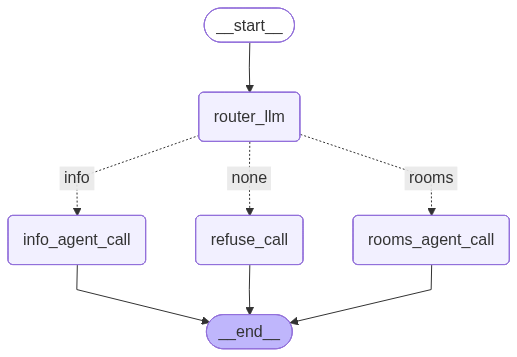

In [21]:
from IPython.display import Image, display

display(Image(agent_built.get_graph().draw_mermaid_png()))

In [14]:
state = agent_built.invoke({"messages": [HumanMessage(content="What's your room service like?")]})
state

{'messages': [HumanMessage(content="What's your room service like?", additional_kwargs={}, response_metadata={}, id='fb4382c0-d854-4cbe-89b2-25c3cff6f3e4'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 352, 'total_tokens': 378, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'id': 'chatcmpl-CpiOmzWGfXLbw21G2pCgsFGQLHxWZ', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b481d-3f99-73f2-bab4-f2d9c0bf440b-0', tool_calls=[{'name': 'query_hotel_info', 'args': {'query': 'room service'}, 'id': 'call_6zTVnHlCAr19lM5HsvdX7VKO', 'type': 'tool_call'}], usage_metadata={'input_tokens': 352, 'output_tokens': 26, 'total_

In [19]:
state = agent_built.invoke({"messages": [HumanMessage(content="What is the answer to the ultimate question of life, the universe, and everything?")]})
state

{'messages': [HumanMessage(content='What is the answer to the ultimate question of life, the universe, and everything?', additional_kwargs={}, response_metadata={}, id='9f2fce40-5515-4bec-9f9e-18a309e62ffd'),
  AIMessage(content="I'm sorry, I cannot help with that query. I can only provide information about the hotel and help with room bookings.", additional_kwargs={}, response_metadata={})],
 'route': 'none'}

In [20]:
state = agent_built.invoke({"messages": [HumanMessage(content="What is the name of the hotel?")]})
state

{'messages': [HumanMessage(content='What is the name of the hotel?', additional_kwargs={}, response_metadata={}, id='33112923-a548-4ce5-a4ae-310d14ded972'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 26, 'prompt_tokens': 354, 'total_tokens': 380, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.1-2025-11-13', 'system_fingerprint': None, 'id': 'chatcmpl-CpiXE42hAHLRjDYslrIonOnecFnm6', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019b4825-413d-7a50-9b4e-b6a19fc97a94-0', tool_calls=[{'name': 'query_hotel_info', 'args': {'query': 'hotel name'}, 'id': 'call_X4pRuEnLNUFwEbET0wb3pvHI', 'type': 'tool_call'}], usage_metadata={'input_tokens': 354, 'output_tokens': 26, 'total_to